In [ ]:
import pandas as pd
import numpy as np
import networkx as nx


df = pd.read_csv("../dataset/tnet_malawi_pilot.csv")
print("Taille brute :", df.shape)

# supprimer colonnes inutiles si présentes
df = df.drop(columns=["Unnamed: 0"], errors="ignore")


df = df[df["contact_time"] > 0]

print("Après retrait contact_time = 0 :", df.shape)


df_agg = df.groupby(["id1", "id2"])["contact_time"].sum().reset_index()
df_agg.rename(columns={"contact_time": "weight"}, inplace=True)

print("Après agrégation :", df_agg.shape)


G = nx.from_pandas_edgelist(df_agg, source="id1", target="id2")
Gw = nx.from_pandas_edgelist(df_agg, source="id1", target="id2", edge_attr="weight")

print("\n=========== GRAPHE FINAL (VERSION ARTICLE) ===========")
print("Nombre de nœuds :", G.number_of_nodes())
print("Nombre d'arêtes :", G.number_of_edges())


components = list(nx.connected_components(G))
print("\nLe graphe est connexe :", nx.is_connected(G))
print("Nombre de composantes :", len(components))
print("Taille de la composante géante :", len(max(components, key=len)))


Taille brute : (102293, 5)
Après retrait contact_time = 0 : (102292, 4)
Après agrégation : (347, 3)

=========== GRAPHE FINAL (VERSION ARTICLE) ===========
Nombre de nœuds : 86
Nombre d'arêtes : 347

Le graphe est connexe : False
Nombre de composantes : 2
Taille de la composante géante : 84


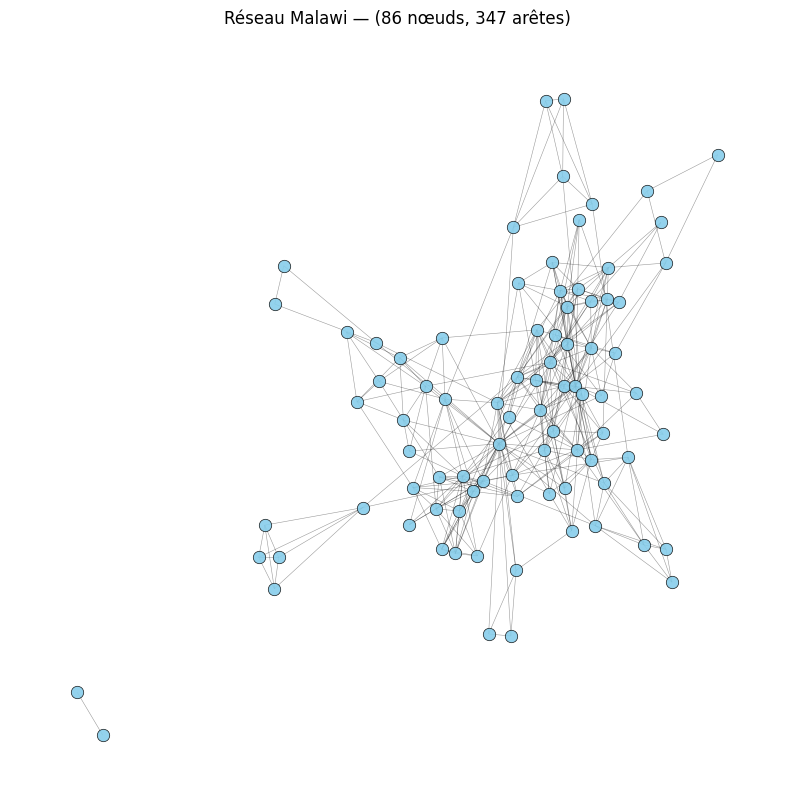

In [ ]:


import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(10, 10))

# Layout stable
pos = nx.spring_layout(G, seed=42, k=0.2)  


nx.draw_networkx_nodes(
    G,
    pos,
    node_size=80,
    node_color="skyblue",
    edgecolors="black",
    linewidths=0.5,
    alpha=0.9
)

nx.draw_networkx_edges(
    G,
    pos,
    width=0.4,
    alpha=0.4
)

)

plt.title("Réseau Malawi — (86 nœuds, 347 arêtes)")
plt.axis("off")
plt.show()



===== LOUVAIN =====
Non pondéré :  10 communautés | modularité = 0.5109667881968956
Pondéré     :  22 communautés | modularité = 0.8930072640081208

===== STABILITÉ LOUVAIN =====
Non pondéré : [10, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 10, 10, 9]
Pondéré     : [22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22]


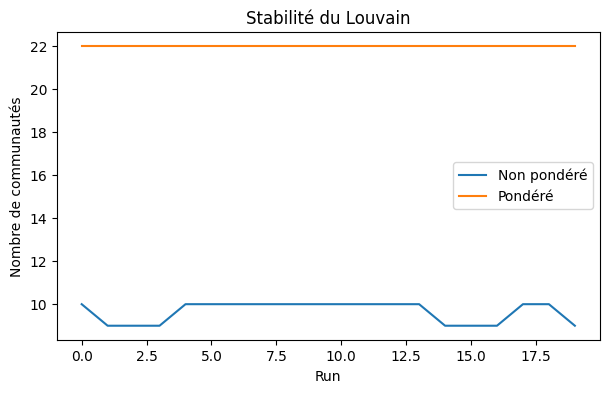


===== WALKTRAP =====
Nombre de communautés : 11
Tailles : [17, 3, 22, 3, 12, 6, 5, 8, 5, 3, 2]


In [ ]:
from community import community_louvain
import matplotlib.pyplot as plt
import igraph as ig

# 1. LOUVAIN (non pondéré + pondéré)

part_unw = community_louvain.best_partition(G)
part_w   = community_louvain.best_partition(Gw, weight="weight")

mod_unw = community_louvain.modularity(part_unw, G)
mod_w   = community_louvain.modularity(part_w, Gw)

print("\n===== LOUVAIN =====")
print("Non pondéré : ", len(set(part_unw.values())), "communautés | modularité =", mod_unw)
print("Pondéré     : ", len(set(part_w.values())),   "communautés | modularité =", mod_w)

# 2. STABILITÉ LOUVAIN SUR 20 RUNS

def louvain_runs(G, weighted=False, n=20):
    results = []
    for _ in range(n):
        if weighted:
            p = community_louvain.best_partition(G, weight="weight")
        else:
            p = community_louvain.best_partition(G)
        results.append(len(set(p.values())))
    return results

runs_unw = louvain_runs(G, weighted=False)
runs_w   = louvain_runs(Gw, weighted=True)

print("\n===== STABILITÉ LOUVAIN =====")
print("Non pondéré :", runs_unw)
print("Pondéré     :", runs_w)

plt.figure(figsize=(7,4))
plt.plot(runs_unw, label="Non pondéré")
plt.plot(runs_w, label="Pondéré")
plt.xlabel("Run")
plt.ylabel("Nombre de communautés")
plt.title("Stabilité du Louvain")
plt.legend()
plt.show()



In [ ]:
# Méthodes basées sur des marches aléatoires

# INFOMAP (flow-based community detection)

from infomap import Infomap

im = Infomap()

# ajouter liens
for u, v in G.edges():
    im.add_link(u, v)

im.run()

# récupérer les communautés
infomap_assign = {
    node.node_id: node.module_id
    for node in im.iterTree()
    if node.isLeaf()
}

infomap_k = len(set(infomap_assign.values()))

print("\n===== INFOMAP =====")
print("Nombre de communautés :", infomap_k)

# tailles des communautés
sizes = {}
for n, c in infomap_assign.items():
    sizes[c] = sizes.get(c, 0) + 1

print("Tailles :", list(sizes.values()))

# 3. WALKTRAP 

# Conversion
g_ig = ig.Graph.TupleList(G.edges(), directed=False)

walktrap = g_ig.community_walktrap().as_clustering()
walk_sizes = walktrap.sizes()

print("\n===== WALKTRAP =====")
print("Nombre de communautés :", len(walk_sizes))
print("Tailles :", walk_sizes)




===== INFOMAP =====
Nombre de communautés : 10
Tailles : [37, 13, 8, 4, 6, 5, 5, 3, 3, 2]

===== WALKTRAP =====
Nombre de communautés : 11
Tailles : [17, 3, 22, 3, 12, 6, 5, 8, 5, 3, 2]
  Infomap v2.8.0 starts at 2025-12-16 09:06:10
  -> Input network: 
  -> No file output!
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'undirected'... 
  -> Using undirected links.
  => Sum node flow: 1, sum link flow: 1
Build internal network with 86 nodes and 347 links...
  -> One-level codelength: 6.17156003

Trial 1/1 starting at 2025-12-16 09:06:10
Two-level compression: 14% 0.44% 
Partitioned to codelength 0.523589729 + 4.73822753 = 5.261817255 in 10 modules.
Super-level compression: to codelength 5.261817255 in 10 top modules.

Recursive sub-structure compression: 0% . Found 2 levels with codelength 5.261817255

=> Trial 1/1 finished in 0.001431792s with codelength 5.26181725


Summary after 1 trial
Best end mod

/Users/mariaboubekeur/miniconda3/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



Spectral Clustering : 10 communautés
Tailles des communautés : [24, 16, 14, 8, 6, 5, 5, 3, 3, 2]

10 plus petites valeurs propres du Laplacien normalisé :
[-0.000000, 0.000000, 0.067425, 0.132788, 0.147327, 0.184823, 0.232372, 0.298524, 0.312749, 0.331314]


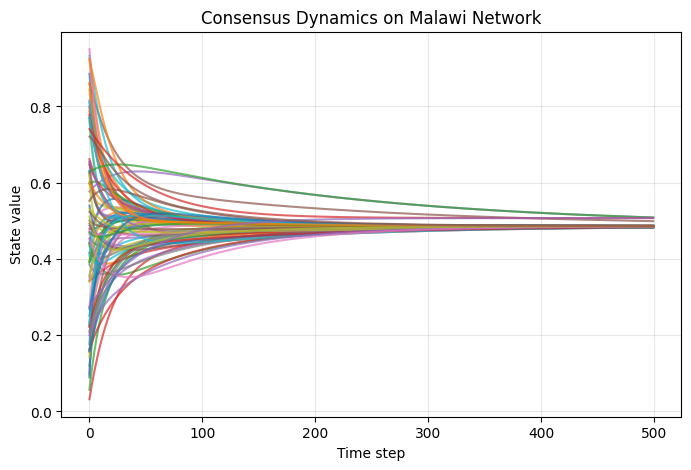

In [ ]:
# 4. ANALYSE SPECTRALE : Spectral Clustering + Laplacien + Consensus

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering

#  SPECTRAL CLUSTERING

A = nx.to_numpy_array(G)   # matrice d’adjacence

k_spec = len(set(part_unw.values()))   # même nb de com. que Louvain non pondéré

spec = SpectralClustering(
    n_clusters=k_spec,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=42          
)

labels = spec.fit_predict(A)
spec_sizes = pd.Series(labels).value_counts().tolist()

print("\nSpectral Clustering :", k_spec, "communautés")
print("Tailles des communautés :", spec_sizes)



#  CALCUL DU SPECTRE DU LAPLACIEN NORMALISÉ

nodes = list(G.nodes())  

L_norm = nx.normalized_laplacian_matrix(G, nodelist=nodes).astype(float).todense()
eigenvalues = np.linalg.eigvals(L_norm)
eigenvalues = np.sort(np.real(eigenvalues))   # valeurs propres triées

# Formatage propre pour LaTeX / rapport
formatted = ", ".join([f"{val:.6f}" for val in eigenvalues[:10]])

print("\n10 plus petites valeurs propres du Laplacien normalisé :")
print(f"[{formatted}]")


#  LAPLACIEN NON NORMALISÉ POUR LA DYNAMIQUE DE CONSENSUS

L = nx.laplacian_matrix(G, nodelist=nodes).astype(float).todense()
L = np.array(L)


# SIMULATION DE LA DYNAMIQUE DE CONSENSUS (x_dot = -L x)

n = len(nodes)
x = np.random.rand(n)  # état initial aléatoire

dt = 0.01
steps = 500

X = np.zeros((steps, n))

for t in range(steps):
    x = x - dt * (L @ x)
    X[t] = x


#  AFFICHAGE DE LA DYNAMIQUE DE CONSENSUS

plt.figure(figsize=(8, 5))
plt.plot(X, alpha=0.7)
plt.title("Consensus Dynamics on Malawi Network")
plt.xlabel("Time step")
plt.ylabel("State value")
plt.grid(alpha=0.3)
plt.show()



=== γ-MODULARITÉ (Markov Stability linéarisée) ===
γ=0.5  →  Q=0.8860,  communautés=26
γ=1.0  →  Q=0.8930,  communautés=22
γ=1.5  →  Q=0.8903,  communautés=23
γ=2.0  →  Q=0.8903,  communautés=23
γ=3.0  →  Q=0.8903,  communautés=23


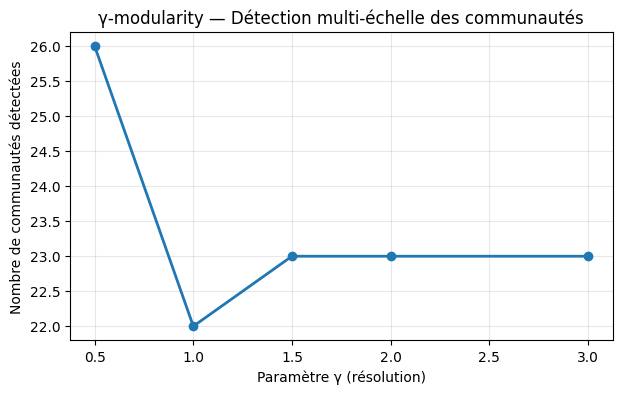

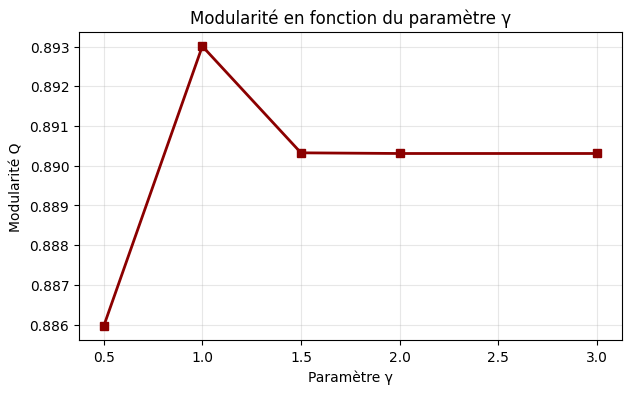

In [ ]:
# Multi-résolution : γ-modularity


import matplotlib.pyplot as plt

gammas = [0.5, 1.0, 1.5, 2.0, 3.0]
gamma_res = []

print("\n=== γ-MODULARITÉ (Markov Stability linéarisée) ===")

for gamma in gammas:
    part = community_louvain.best_partition(
        Gw,
        resolution=gamma,
        weight="weight",
        random_state=42  
    )
    Q = community_louvain.modularity(part, Gw)
    k = len(set(part.values()))
    gamma_res.append((gamma, Q, k))
    print(f"γ={gamma:.1f}  →  Q={Q:.4f},  communautés={k}")

# Plot du nombre de communautés en fonction de γ
plt.figure(figsize=(7, 4))
plt.plot(gammas, [k for (_, _, k) in gamma_res], marker='o', linewidth=2)
plt.xlabel("Paramètre γ (résolution)")
plt.ylabel("Nombre de communautés détectées")
plt.title("γ-modularity — Détection multi-échelle des communautés")
plt.grid(alpha=0.3)
plt.show()

# Plot de la modularité elle-même
plt.figure(figsize=(7, 4))
plt.plot(gammas, [Q for (_, Q, _) in gamma_res], marker='s', linewidth=2, color="darkred")
plt.xlabel("Paramètre γ")
plt.ylabel("Modularité Q")
plt.title("Modularité en fonction du paramètre γ")
plt.grid(alpha=0.3)
plt.show()



=== K-CORE DECOMPOSITION ===
K-core maximal = 7
Taille du noyau (core) : 31
Taille de la périphérie : 2
Périphérie : [72, 10] 


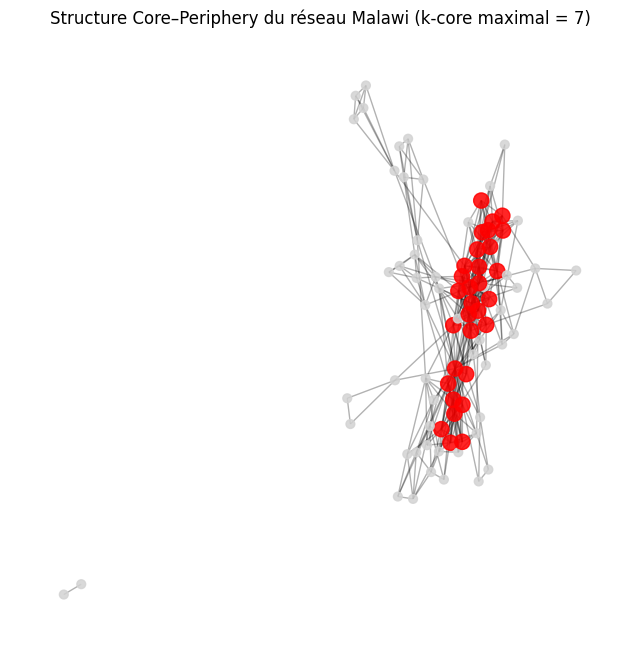

In [ ]:
# Structure interne k-core decomposition & core periphery


print("\n=== K-CORE DECOMPOSITION ===")

core = nx.core_number(G)
maxcore = max(core.values())

# Noeuds du noyau (k-core maximal)
core_nodes = [n for n, c in core.items() if c == maxcore]

# Noeuds de périphérie (k=1)
periphery_nodes = [n for n, c in core.items() if c == 1]

print(f"K-core maximal = {maxcore}")
print(f"Taille du noyau (core) : {len(core_nodes)}")

if len(periphery_nodes) == 0:
    print("Aucune périphérie : tous les nœuds ont un degré de coreness ≥ 2 après nettoyage.")
else:
    print(f"Taille de la périphérie : {len(periphery_nodes)}")
    print("Périphérie :", periphery_nodes[:20], ("..." if len(periphery_nodes) > 20 else ""))

# Visualisation simple du core-periphery
colors = ["red" if core[n] == maxcore else "lightgray" for n in G.nodes()]
sizes = [120 if core[n] == maxcore else 40 for n in G.nodes()]

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, alpha=0.85)
nx.draw_networkx_edges(G, pos, alpha=0.3)

plt.title(f"Structure Core–Periphery du réseau Malawi (k-core maximal = {maxcore})")
plt.axis("off")
plt.show()



Plus grande valeur propre λ_max = 11.9348
Seuil épidémique théorique β/μ > 1/λ_max = 0.0838

Taille composante géante : 84 nœuds

Top 10 superspreaders (GC only) :
    node  degree  eigenvector  stationary
38    16      31     0.257454    0.044798
29    81      26     0.310692    0.037572
14    69      18     0.144373    0.026012
17    74      17     0.233784    0.024566
16    70      16     0.223744    0.023121
0      1      16     0.182215    0.023121
20    52      15     0.204488    0.021676
79    63      15     0.213809    0.021676
9     86      15     0.137245    0.021676
4     33      14     0.216434    0.020231

Superspreader choisi : 16
Nœud périphérique choisi : 67


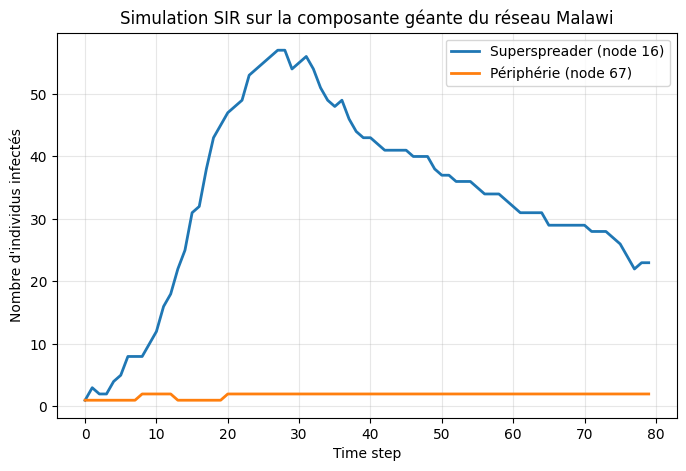

In [ ]:
#  ÉPIDÉMIES SUR RÉSEAUX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# 6.1 Calcul du plus grand eigenvalue λ_max (seuil épidémique)

A = nx.to_numpy_array(G)     
eigs = np.linalg.eigvals(A)
lambda_max = np.max(np.real(eigs))

print(f"\nPlus grande valeur propre λ_max = {lambda_max:.4f}")
print(f"Seuil épidémique théorique β/μ > 1/λ_max = {1/lambda_max:.4f}")


# Identification des superspreaders (sur composante géante)

# Extraire la plus grande composante connexe
giant = max(nx.connected_components(G), key=len)
G_gc = G.subgraph(giant).copy()

print(f"\nTaille composante géante : {len(G_gc.nodes())} nœuds")

# Centralités (toutes définies sur un graphe connexe)
deg_cent = dict(G_gc.degree())
eig_cent = nx.eigenvector_centrality_numpy(G_gc)
rw_stat = {n: deg_cent[n] / sum(deg_cent.values()) for n in G_gc.nodes()}

df_sup = pd.DataFrame({
    "node": list(G_gc.nodes()),
    "degree": [deg_cent[n] for n in G_gc.nodes()],
    "eigenvector": [eig_cent[n] for n in G_gc.nodes()],
    "stationary": [rw_stat[n] for n in G_gc.nodes()]
}).sort_values(by="stationary", ascending=False)

print("\nTop 10 superspreaders (GC only) :")
print(df_sup.head(10))

super_node = int(df_sup.iloc[0]["node"])
periph_node = int(df_sup.iloc[-1]["node"])

print(f"\nSuperspreader choisi : {super_node}")
print(f"Nœud périphérique choisi : {periph_node}")


# Simulation SIR 

def run_SIR(G, patient_zero, beta=0.03, mu=0.02, steps=80):
    """Simule un processus SIR sur un graphe donné."""
    status = {n: "S" for n in G.nodes()}
    status[patient_zero] = "I"

    infected_counts = []

    for _ in range(steps):
        new_status = status.copy()

        for n in G.nodes():
            if status[n] == "I":

                # guérison
                if np.random.rand() < mu:
                    new_status[n] = "R"

                # infection des voisins
                for neigh in G.neighbors(n):
                    if status[neigh] == "S" and np.random.rand() < beta:
                        new_status[neigh] = "I"

        status = new_status
        infected_counts.append(sum(1 for v in status.values() if v == "I"))

    return infected_counts


# L’épidémie doit être simulée sur la composante géante
I_super = run_SIR(G_gc, super_node)
I_periph = run_SIR(G_gc, periph_node)


# -------------------------------------------------------------
# 6.4 Visualisation
# -------------------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(I_super, label=f"Superspreader (node {super_node})", linewidth=2)
plt.plot(I_periph, label=f"Périphérie (node {periph_node})", linewidth=2)
plt.xlabel("Time step")
plt.ylabel("Nombre d'individus infectés")
plt.title("Simulation SIR sur la composante géante du réseau Malawi")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
